In [10]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

# add more if needed

In [11]:
adata = ad.read_h5ad("/Users/dm954/Documents/code/mixed_diffusion/data/neo_cortex/polioudakis_cleaned.h5ad")
adata2 = ad.read_h5ad("/Users/dm954/Documents/code/mixed_diffusion/data/neo_cortex/nowakowski_cleaned.h5ad")

In [12]:
# print out whether the genes match
assert all(adata.var_names == adata2.var_names)

In [13]:
matrix1 = adata.X
matrix2 = adata2.X

meta1 = adata.obs
meta2 = adata2.obs

In [14]:
adata.obs

,cell_type_transferred
observations,
CTGTCAGAATAA,oRG
GGGCAGATGTTA,tRG
TTGAGCGGTACC,vRG
GTGCATATGAGG,tRG
TTTAGAAGCGGA,vRG
...,...
TGAGGTTATTGG,Microglia
ACGACCCTAGTG,Microglia
CCCTCGTTAGAG,Microglia


In [15]:
# merge matrix1 and matrix2 and observations into matrix 

# Merge matrix1 and matrix2
matrix = np.vstack([matrix1, matrix2])

# Assign train and test sets
C_test = matrix1
C_train = matrix2

# Create indices to track which samples come from which dataset
test_indices = np.arange(0, matrix1.shape[0])  # First part: matrix1 indices
train_indices = np.arange(matrix1.shape[0], matrix1.shape[0] + matrix2.shape[0])  # Second part: matrix2 indices

# Stack the labels from both datasets to match the merged matrix
labels_test = pd.DataFrame({'x': meta1['cell_type_transferred']})  # Labels for matrix1 (test set)
labels_train = pd.DataFrame({'x': meta2['majortype3']})  # Labels for matrix2 (train set)
labels_df = pd.concat([labels_test, labels_train], axis=0, ignore_index=True)  # Combined labels

print("Merged matrix shape:", matrix.shape)
print("Test set shape (matrix1):", C_test.shape)
print("Train set shape (matrix2):", C_train.shape)
print("Test labels shape:", labels_test.shape)
print("Train labels shape:", labels_train.shape)
print("Test indices range:", test_indices.min(), "to", test_indices.max())
print("Train indices range:", train_indices.min(), "to", train_indices.max())
print("Total samples:", len(test_indices) + len(train_indices))


Merged matrix shape: (18621, 785)
Test set shape (matrix1): (15126, 785)
Train set shape (matrix2): (3495, 785)
Test labels shape: (15126, 1)
Train labels shape: (3495, 1)
Test indices range: 0 to 15125
Train indices range: 15126 to 18620
Total samples: 18621


In [21]:
# Save all the split data
np.save(f'C_train.npy', C_train)
np.save(f'C_test.npy', C_test)

# Save labels as CSV files
labels_train.to_csv('labels_train.csv', index=False)
labels_test.to_csv('labels_test.csv', index=False)

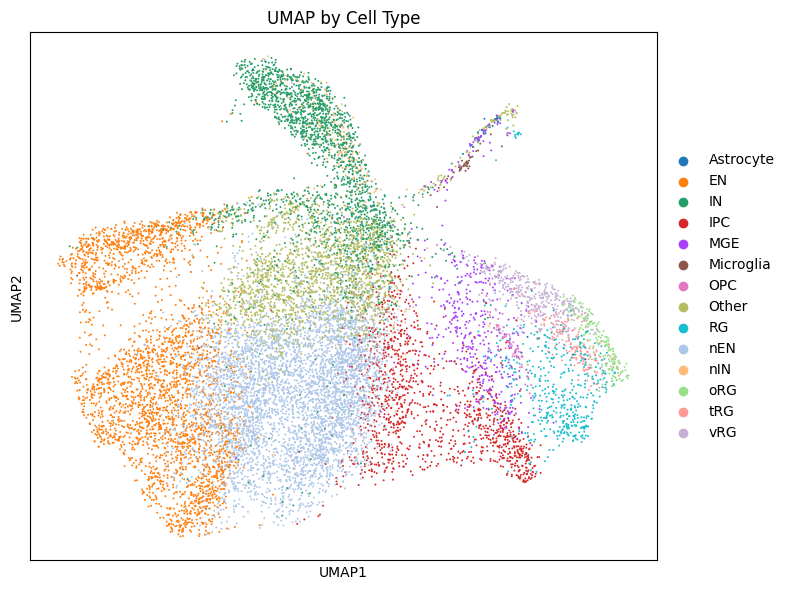

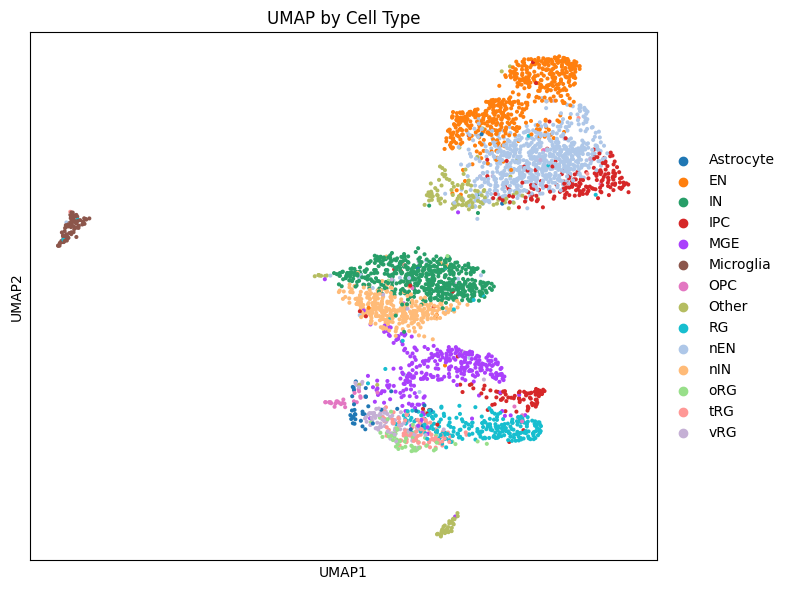

In [27]:
# -------------------------
# PCA and UMAP on Harmony-corrected data
# -------------------------
from sklearn.decomposition import PCA

def umap_plot(adata1, key):
    sc.tl.pca(adata1, n_comps=30, random_state=42)
    sc.pp.neighbors(adata1, n_neighbors=15, n_pcs=30)
    sc.tl.umap(adata1, random_state=42)
    # --- Plot UMAPs by batch and by cell type ---
    fig, ax = plt.subplots(figsize=(8, 6))  # 12in wide × 6in tall
    sc.pl.umap(adata1, color=key, show=False, title="UMAP by Cell Type", ax=ax)
    plt.tight_layout()

    plt.show()

umap_plot(adata, 'cell_type_transferred')
umap_plot(adata2, 'majortype3')

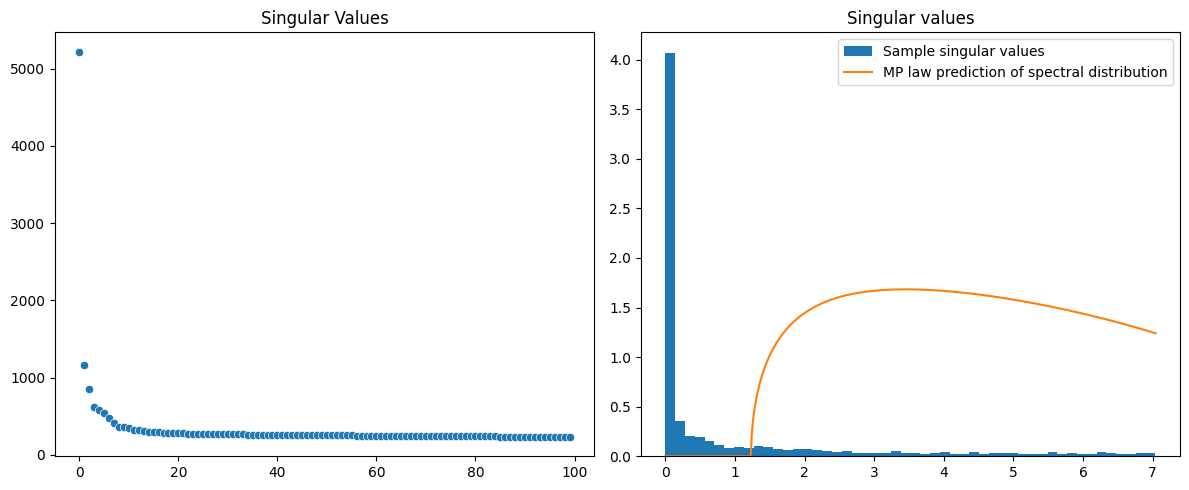

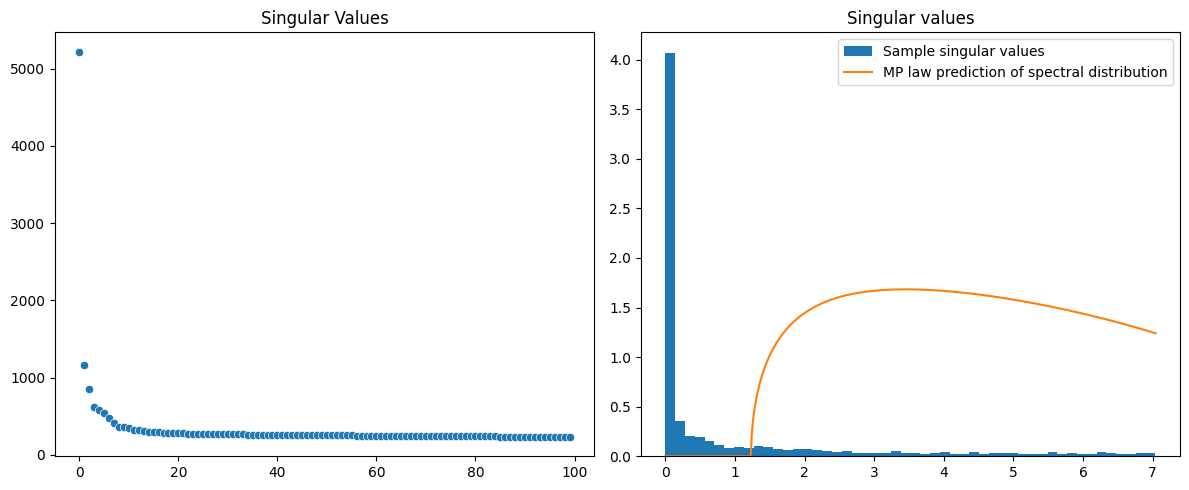

In [ ]:

def plot_singular_values(adata):
    C = adata.X

    ## Studying the dominant rna PC's

    U2_init_bn, S2_init_bn, V2_init_bn = np.linalg.svd(C, full_matrices = False)
    plot_svd = S2_init_bn[:100]

    PCA_components_for_denoising = 400

    k_C = PCA_components_for_denoising
    n_features_C = C.shape[1]
    n_samples_C = C.shape[0]
    C_residual = C-U2_init_bn[:,:k_C] @ np.diag(S2_init_bn[:k_C]) @ V2_init_bn[:k_C,:]
    # use tau_sq_correct_C as rho
    tau_sq_correct_C = np.sum(C_residual**2) / n_features_C 
    C_residual = C_residual/np.sqrt(tau_sq_correct_C)
    U2_init_res_C, S2_init_res_C, V2_init_res_C = np.linalg.svd(C_residual, full_matrices = False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # First plot - singular values scatter
    sns.scatterplot(data=plot_svd, ax=ax1)
    ax1.set_title("Singular Values")

    # Second plot - histogram with MP law
    sq_singular_val_C = S2_init_res_C ** 2
    shorter_side_C = min(n_samples_C, n_features_C)
    ax2.hist(sq_singular_val_C[:shorter_side_C], density = True, bins = 50, label = "Sample singular values")
    x = np.linspace(sq_singular_val_C.min(), sq_singular_val_C.max(), num = 500)
    aspect_ratio = n_features_C / n_samples_C
    if aspect_ratio > 1:
        scaler = aspect_ratio
    else:
        scaler = 1
    def sqrtMPlaw(x, n_samples, n_features):
        """Square root of Marchenko-Pastur law density"""
        gamma = n_samples / n_features
        lambda_plus = (1 + np.sqrt(gamma))**2
        lambda_minus = (1 - np.sqrt(gamma))**2
        
        density = np.zeros_like(x)
        mask = (x >= lambda_minus) & (x <= lambda_plus)
        density[mask] = np.sqrt(gamma / (2 * np.pi * x[mask])) * np.sqrt((lambda_plus - x[mask]) * (x[mask] - lambda_minus))
        
        return density

    ax2.plot(x, scaler*np.array(sqrtMPlaw(x, n_samples_C, n_features_C)), label="MP law prediction of spectral distribution")
    ax2.legend()
    ax2.set_title("Singular values") 

    plt.tight_layout()
    plt.show()

plot_singular_values(adata)
plot_singular_values(adata2)

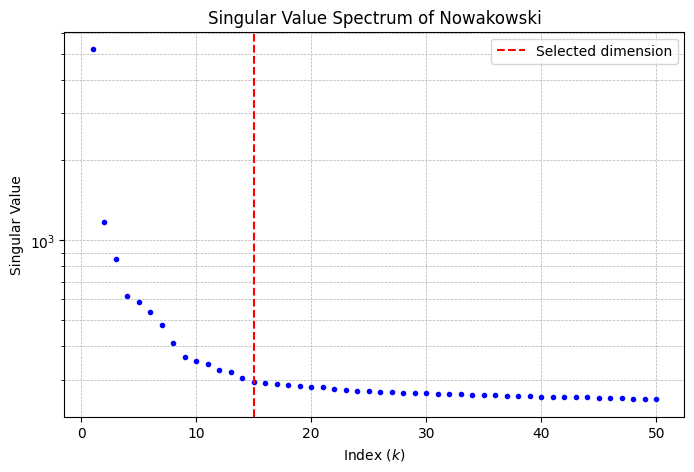

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# S is the array of singular values (assumed to be sorted)
S = np.linalg.svd(C_train, compute_uv=False)[:50]

plt.figure(figsize=(8, 5))
# Use np.arange for the x-axis indices starting from 1
indices = np.arange(1, len(S) + 1)

# *** The crucial step: use semilogy ***
plt.semilogy(indices, S, marker='o', linestyle='', markersize=3, color='blue')

# Labeling
plt.title('Singular Value Spectrum of Nowakowski')
plt.xlabel('Index ($k$)')
plt.ylabel('Singular Value')

# Add Grid
plt.grid(True, which="both", ls="--", linewidth=0.5)

# Optional: Annotate the "effective rank" (e.g., k=50)
effective_rank = 50
plt.axvline(x=15, color='r', linestyle='--', label=f'Selected dimension')
plt.legend()

plt.savefig('svd_nowakowski.pdf')
plt.show()